# Lab 1: Exploratory Data Analysis, Data Quality & Pre Processing for Machine Learning

## Learning Outcomes
By the end of this lab students will be able to:
- Inspect and understand datasets
- Perform Exploratory Data Analysis (EDA)
- Assess data quality
- Handle missing values
- Engineer meaningful features
- Process categorical variables
- Produce an ML-ready dataset


# A. Exploratory Data Analysis (EDA)

In [ ]:
import gdown
import pandas as pd

file_id = "1t5mmVocO1_fGXGqRftpekRom9yxq-ML4"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "student_clean_dataset.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1t5mmVocO1_fGXGqRftpekRom9yxq-ML4
To: /content/student_clean_dataset.csv
100%|██████████| 19.1k/19.1k [00:00<00:00, 31.8MB/s]


'student_clean_dataset.csv'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
df = pd.read_csv("student_clean_dataset.csv")

In [ ]:
df

,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00
1,ST002,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00
2,ST003,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00
3,ST004,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39
4,ST005,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
295,ST296,18,Male,Computer Science,8,86,16,74,Pass,A,Not Placed,0.00
296,ST297,19,Female,Computer Science,9,80,19,92,Pass,A+,Placed,19.43
297,ST298,18,Male,Mechanical,9,81,20,94,Pass,A+,Placed,14.97
298,ST299,19,Male,Computer Science,6,82,18,82,Pass,A+,Placed,7.40


In [ ]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Department', 'Study_Hours',
       'Attendance', 'Assignments', 'Exam_Score', 'Result', 'Grade',
       'Placement', 'LPA'],
      dtype='object')

In [ ]:
print(df["Exam_Score"].min())

14


In [ ]:
df["Result"] = np.where(df["Exam_Score"] >= 33, "Pass", "Fail")

In [ ]:
df.head()
df.tail()
print(df.shape)
print(df.columns)
df.describe()
print(df["Exam_Score"].mean())
print(df["Exam_Score"].median())
print(df["Gender"].value_counts())
print(df["Department"].value_counts())
print(df["Result"].value_counts())
df.corr(numeric_only=True)

(300, 12)
Index(['Student_ID', 'Age', 'Gender', 'Department', 'Study_Hours',
       'Attendance', 'Assignments', 'Exam_Score', 'Result', 'Grade',
       'Placement', 'LPA'],
      dtype='object')
63.20666666666666
64.0
Gender
Male      172
Female    128
Name: count, dtype: int64
Department
Computer Science          117
Information Technology     80
Electronics                52
Mechanical                 51
Name: count, dtype: int64
Result
Pass    282
Fail     18
Name: count, dtype: int64


,Age,Study_Hours,Attendance,Assignments,Exam_Score,LPA
Age,1.000000,-0.003766,0.002616,0.065806,0.040173,-0.005790
Study_Hours,-0.003766,1.000000,0.042219,0.865142,0.902870,0.694327
Attendance,0.002616,0.042219,1.000000,0.024519,0.164536,0.110873
Assignments,0.065806,0.865142,0.024519,1.000000,0.966814,0.684403
Exam_Score,0.040173,0.902870,0.164536,0.966814,1.000000,0.719481
LPA,-0.005790,0.694327,0.110873,0.684403,0.719481,1.000000


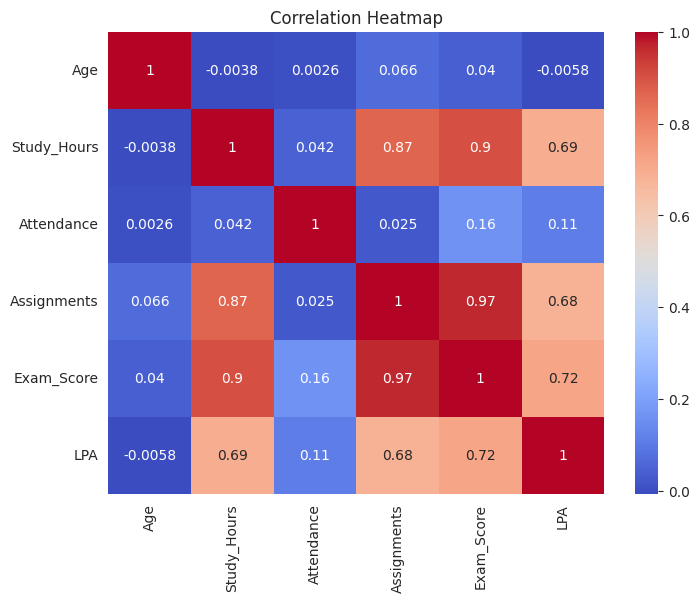

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

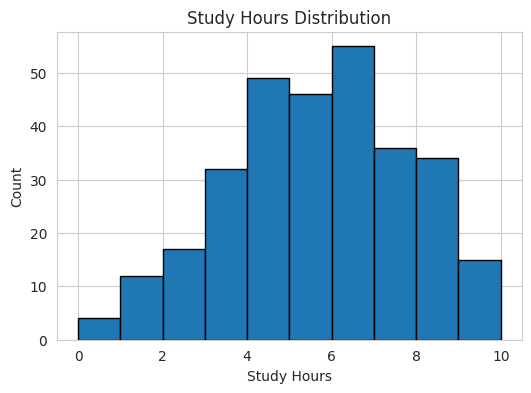

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Study_Hours"], edgecolor="black")
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Count")
plt.show()

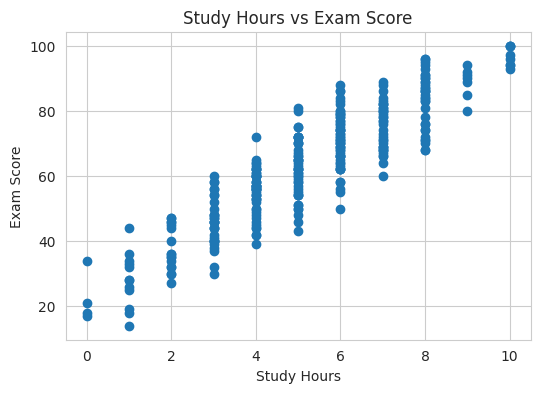

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["Study_Hours"],df["Exam_Score"])
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

remove -2 from study hours

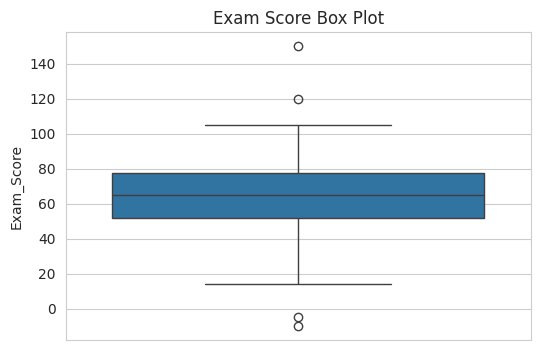

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Exam_Score"])
plt.title("Exam Score Box Plot")
plt.show()

In [ ]:
print("Exam Score Summary")
print("-" * 30)
print(f"Minimum      : {df['Exam_Score'].min()}")
print(f"25th Percent : {df['Exam_Score'].quantile(0.25):.1f}")
print(f"Median (50%) : {df['Exam_Score'].median():.1f}")
print(f"75th Percent : {df['Exam_Score'].quantile(0.75):.1f}")
print(f"Maximum      : {df['Exam_Score'].max()}")

Exam Score Summary
------------------------------
Minimum      : 14
25th Percent : 50.8
Median (50%) : 64.0
75th Percent : 76.0
Maximum      : 100


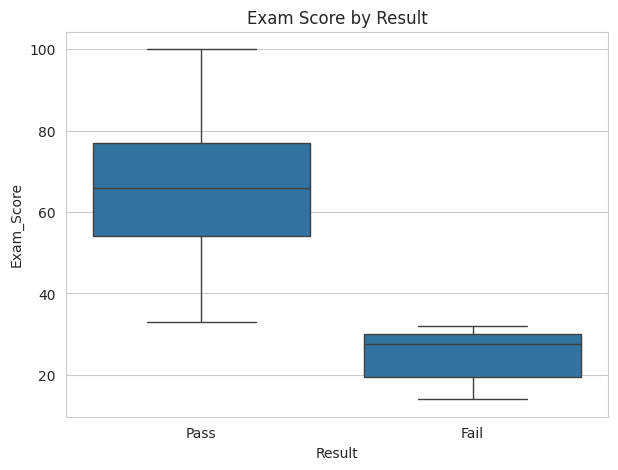

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df,x="Result",y="Exam_Score")
plt.title("Exam Score by Result")
plt.show()

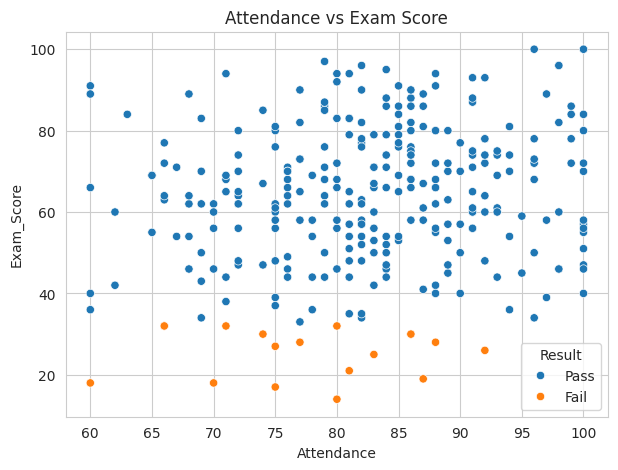

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,x="Attendance",y="Exam_Score",hue="Result")
plt.title("Attendance vs Exam Score")
plt.show()

# B. Data Quality Assessment

This notebook demonstrates common data quality issues and how to identify and fix them before machine learning.

In [ ]:
file_id = "1FDlcHX8C1tFCVr6T7g6Nd3EWKh4-N_Ww"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "student_raw_dataset.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1FDlcHX8C1tFCVr6T7g6Nd3EWKh4-N_Ww
To: /content/student_raw_dataset.csv
100%|██████████| 22.2k/22.2k [00:00<00:00, 12.4MB/s]


'student_raw_dataset.csv'

In [ ]:
df = pd.read_csv("student_raw_dataset.csv")


## 1. Inspect Dataset


In [ ]:
df.info()
print("\nData Types:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   310 non-null    object 
 1   Age          286 non-null    float64
 2   Gender       294 non-null    object 
 3   Department   295 non-null    object 
 4   Study_Hours  295 non-null    float64
 5   Attendance   294 non-null    float64
 6   Assignments  295 non-null    float64
 7   Exam_Score   295 non-null    float64
 8   Result       310 non-null    object 
 9   Grade        310 non-null    object 
 10  Placement    310 non-null    object 
 11  LPA          310 non-null    float64
dtypes: float64(6), object(6)
memory usage: 29.2+ KB

Data Types:
Student_ID      object
Age            float64
Gender          object
Department      object
Study_Hours    float64
Attendance     float64
Assignments    float64
Exam_Score     float64
Result          object
Grade           object
Placement  


## 2. Missing Values


In [ ]:
df.isna().sum()

,0
Student_ID,0
Age,24
Gender,16
Department,15
Study_Hours,15
Attendance,16
Assignments,15
Exam_Score,15
Result,0
Grade,0



## 3. Duplicate Rows


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 4



## Remove Duplicate Rows


In [ ]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (306, 12)



## 4. Check Categories


In [ ]:
print(df["Department"].unique())
print(df["Department"].value_counts())
print("Sum is: ", df["Department"].value_counts().sum())

['COMPUTER SCIENCE' 'Computer Science' 'Information Technology'
 'information technology' 'Electronics ' ' Electronics' 'Electronics'
 'Mechanical' 'INFORMATION TECHNOLOGY' nan 'Information Technology '
 'Computer Science ' 'ELECTRONICS' 'electronics' 'computer science'
 ' Information Technology' 'Mechanical ' 'mechanical' ' Computer Science']
Department
Computer Science           102
Information Technology      64
Mechanical                  46
Electronics                 42
ELECTRONICS                  5
Computer Science             5
COMPUTER SCIENCE             4
INFORMATION TECHNOLOGY       4
 Electronics                 3
 Computer Science            3
Mechanical                   2
Information Technology       2
information technology       2
electronics                  2
 Information Technology      2
Electronics                  1
computer science             1
mechanical                   1
Name: count, dtype: int64
Sum is:  291



## 5. Clean Category Values


In [ ]:
for col in ["Gender","Department","Result","Placement"]:
    df[col]=(df[col]
             .str.lower()
             .str.strip())

print(df["Department"].value_counts())
print("Rows after cleaning:",len(df))
print("After Cleaning is: ", df["Department"].value_counts().sum())

Department
computer science          115
information technology     74
electronics                53
mechanical                 49
Name: count, dtype: int64
Rows after cleaning: 306
After Cleaning is:  291



## 6. Incorrect Data Types


In [ ]:
num_cols=["Age","Study_Hours","Attendance","Assignments","Exam_Score"]
for col in num_cols:
    df[col]=pd.to_numeric(df[col],errors="coerce")

print(df.dtypes)

Student_ID      object
Age            float64
Gender          object
Department      object
Study_Hours    float64
Attendance     float64
Assignments    float64
Exam_Score     float64
Result          object
Grade           object
Placement       object
LPA            float64
dtype: object



## 7. Domain Validation


In [ ]:
print("Invalid Age")
display(df[(df.Age<17)|(df.Age>20)])

print("Invalid Study Hours")
display(df[(df.Study_Hours<0)|(df.Study_Hours>10)])

print("Invalid Attendance")
display(df[(df.Attendance<60)|(df.Attendance>100)])

print("Invalid Assignments")
display(df[(df.Assignments<0)|(df.Assignments>20)])

print("Invalid Exam Score")
display(df[(df.Exam_Score<0)|(df.Exam_Score>100)])

Invalid Age


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
106,ST107,99.0,male,computer science,6.0,77.0,15.0,73.0,pass,A,placed,6.16
120,ST121,-2.0,female,mechanical,NaN,NaN,12.0,58.0,pass,C,placed,4.66
222,ST223,-5.0,female,computer science,7.0,72.0,NaN,80.0,pass,A+,placed,7.23
269,ST270,200.0,male,mechanical,4.0,88.0,14.0,NaN,pass,B,placed,5.17
303,ST010,150.0,male,electronics,4.0,89.0,10.0,45.0,pass,D,not placed,0.00


Invalid Study Hours


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
95,ST096,18.0,female,electronics,-2.0,100.0,9.0,40.0,pass,D,not placed,0.00
102,ST010,18.0,male,computer science,15.0,79.0,25.0,86.0,pass,A+,placed,8.13
121,ST122,19.0,female,computer science,-5.0,96.0,11.0,50.0,pass,C,not placed,0.00
199,ST200,19.0,female,mechanical,12.0,NaN,9.0,47.0,pass,D,not placed,0.00
228,ST229,19.0,male,electronics,20.0,75.0,13.0,56.0,pass,C,not placed,0.00


Invalid Attendance


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
21,ST022,17.0,female,computer science,5.0,150.0,10.0,46.0,pass,D,not placed,0.00
59,ST060,18.0,male,information technology,6.0,120.0,16.0,74.0,pass,A,placed,5.68
70,ST071,19.0,male,NaN,6.0,-5.0,15.0,64.0,pass,B,placed,5.07
122,ST123,18.0,male,computer science,8.0,-10.0,15.0,68.0,pass,B,placed,5.53
304,ST234,NaN,male,computer science,3.0,105.0,7.0,46.0,pass,D,not placed,0.00


Invalid Assignments


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
102,ST010,18.0,male,computer science,15.0,79.0,25.0,86.0,pass,A+,placed,8.13
143,ST144,18.0,male,information technology,6.0,87.0,50.0,86.0,pass,A+,placed,9.65
158,ST159,18.0,male,mechanical,5.0,92.0,-5.0,72.0,pass,A,placed,6.08
176,ST177,19.0,male,computer science,4.0,93.0,-3.0,60.0,pass,B,placed,4.59
206,ST207,17.0,female,mechanical,5.0,80.0,30.0,66.0,pass,B,placed,4.81


Invalid Exam Score


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
84,ST085,18.0,female,mechanical,6.0,100.0,17.0,120.0,pass,A+,placed,7.83
252,ST253,19.0,male,computer science,6.0,84.0,16.0,-5.0,pass,A,placed,6.43
293,ST294,18.0,male,information technology,NaN,85.0,16.0,150.0,pass,A,placed,5.81
294,ST295,17.0,female,electronics,1.0,88.0,6.0,105.0,fail,F,not placed,0.00
309,ST176,NaN,female,computer science,5.0,81.0,14.0,-10.0,pass,B,placed,5.66



## 8. Practical Validation


In [ ]:
print(df.isna().sum())
print("\nDuplicate Rows:",df.duplicated().sum())
print("\nDepartment Counts")
print(df["Department"].value_counts())

Student_ID      0
Age            20
Gender         15
Department     15
Study_Hours    15
Attendance     16
Assignments    15
Exam_Score     15
Result          0
Grade           0
Placement       0
LPA             0
dtype: int64

Duplicate Rows: 3

Department Counts
Department
computer science          115
information technology     74
electronics                53
mechanical                 49
Name: count, dtype: int64



# C. Missing Data Handling

This notebook demonstrates detection and handling of missing values using deletion and various imputation techniques.



## 1. Detect Missing Values


In [ ]:
print("Missing Value Count")
print(df.isna().sum())

print("\nPercentage of Missing Values")
print((df.isna().mean()*100).round(2).astype(str)+" %")



Missing Value Count
Student_ID      0
Age            20
Gender         15
Department     15
Study_Hours    15
Attendance     16
Assignments    15
Exam_Score     15
Result          0
Grade           0
Placement       0
LPA             0
dtype: int64

Percentage of Missing Values
Student_ID      0.0 %
Age            6.54 %
Gender          4.9 %
Department      4.9 %
Study_Hours     4.9 %
Attendance     5.23 %
Assignments     4.9 %
Exam_Score      4.9 %
Result          0.0 %
Grade           0.0 %
Placement       0.0 %
LPA             0.0 %
dtype: object



## 2. Delete Rows with Missing Values

In [ ]:
deleted_df = df.dropna()

print("Original Shape:", df.shape)
print("After dropna():", deleted_df.shape)

deleted_df.head()

Original Shape: (306, 12)
After dropna(): (211, 12)


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18.0,male,computer science,3.0,98.0,12.0,60.0,pass,B,not placed,0.00
1,ST002,20.0,male,computer science,1.0,81.0,11.0,44.0,pass,D,not placed,0.00
3,ST004,19.0,female,computer science,5.0,100.0,10.0,51.0,pass,C,placed,3.39
4,ST005,18.0,female,computer science,5.0,68.0,13.0,54.0,pass,C,placed,3.12
6,ST007,17.0,male,computer science,7.0,86.0,15.0,68.0,pass,B,not placed,0.00



## 3. Fill Missing Values with a Constant


In [ ]:
print("Original Shape:", df.shape)
print("Actual NaN :", df["Department"].isna().sum())

Original Shape: (306, 12)
Actual NaN : 15


In [ ]:
constant_df = df.copy()

constant_df["Department"] = constant_df["Department"].fillna("Unknown")

constant_df[constant_df["Department"] == "Unknown"].head()

,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
30,ST031,19.0,male,Unknown,3.0,88.0,8.0,42.0,pass,D,not placed,0.00
70,ST071,19.0,male,Unknown,6.0,-5.0,15.0,64.0,pass,B,placed,5.07
99,ST100,17.0,female,Unknown,5.0,83.0,13.0,60.0,pass,B,not placed,0.00
103,ST104,18.0,female,Unknown,6.0,65.0,17.0,69.0,pass,B,placed,4.57
138,ST139,18.0,female,Unknown,2.0,69.0,8.0,34.0,fail,F,not placed,0.00


Imputation vs Deletion

If missing values <5%, imputation is generally acceptable.

If missing values >50%, evaluate whether the feature should be retained.



## 4. Mean Imputation


In [ ]:
print(df["Age"].isna().sum())

20


In [ ]:
mean_df = df.copy()

mean_df["Age"] = mean_df["Age"].fillna(mean_df["Age"].mean())

mean_df

,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18.000000,male,computer science,3.0,98.0,12.0,60.0,pass,B,not placed,0.00
1,ST002,20.000000,male,computer science,1.0,81.0,11.0,44.0,pass,D,not placed,0.00
2,ST003,19.000000,NaN,computer science,NaN,76.0,9.0,46.0,pass,D,not placed,0.00
3,ST004,19.000000,female,computer science,5.0,100.0,10.0,51.0,pass,C,placed,3.39
4,ST005,18.000000,female,computer science,5.0,68.0,13.0,54.0,pass,C,placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
301,ST267,19.611888,male,computer science,7.0,66.0,19.0,77.0,pass,A,placed,6.51
303,ST010,150.000000,male,electronics,4.0,89.0,10.0,45.0,pass,D,not placed,0.00
304,ST234,19.611888,male,computer science,3.0,105.0,7.0,46.0,pass,D,not placed,0.00
308,ST006,19.611888,female,information technology,8.0,NaN,20.0,91.0,pass,A+,placed,16.19



## 5. Median Imputation


In [ ]:
median_df = df.copy()

median_df["Age"] = median_df["Age"].fillna(median_df["Age"].median())

median_df

,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18.0,male,computer science,3.0,98.0,12.0,60.0,pass,B,not placed,0.00
1,ST002,20.0,male,computer science,1.0,81.0,11.0,44.0,pass,D,not placed,0.00
2,ST003,19.0,NaN,computer science,NaN,76.0,9.0,46.0,pass,D,not placed,0.00
3,ST004,19.0,female,computer science,5.0,100.0,10.0,51.0,pass,C,placed,3.39
4,ST005,18.0,female,computer science,5.0,68.0,13.0,54.0,pass,C,placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
301,ST267,18.0,male,computer science,7.0,66.0,19.0,77.0,pass,A,placed,6.51
303,ST010,150.0,male,electronics,4.0,89.0,10.0,45.0,pass,D,not placed,0.00
304,ST234,18.0,male,computer science,3.0,105.0,7.0,46.0,pass,D,not placed,0.00
308,ST006,18.0,female,information technology,8.0,NaN,20.0,91.0,pass,A+,placed,16.19


## 6. Mode Imputation

In [ ]:
mode_df = df.copy()

mode_df["Department"] = mode_df["Department"].fillna(mode_df["Department"].mode()[0])

mode_df

,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18.0,male,computer science,3.0,98.0,12.0,60.0,pass,B,not placed,0.00
1,ST002,20.0,male,computer science,1.0,81.0,11.0,44.0,pass,D,not placed,0.00
2,ST003,19.0,NaN,computer science,NaN,76.0,9.0,46.0,pass,D,not placed,0.00
3,ST004,19.0,female,computer science,5.0,100.0,10.0,51.0,pass,C,placed,3.39
4,ST005,18.0,female,computer science,5.0,68.0,13.0,54.0,pass,C,placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
301,ST267,NaN,male,computer science,7.0,66.0,19.0,77.0,pass,A,placed,6.51
303,ST010,150.0,male,electronics,4.0,89.0,10.0,45.0,pass,D,not placed,0.00
304,ST234,NaN,male,computer science,3.0,105.0,7.0,46.0,pass,D,not placed,0.00
308,ST006,NaN,female,information technology,8.0,NaN,20.0,91.0,pass,A+,placed,16.19
